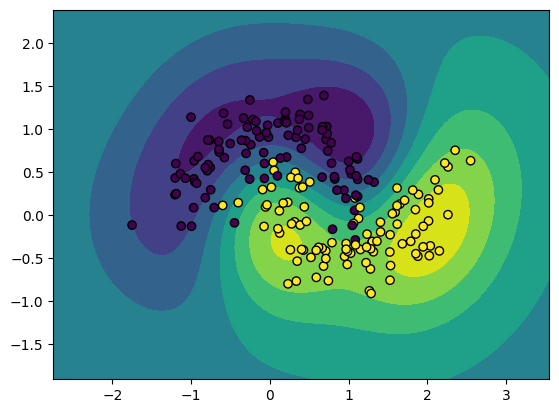

Class weights (λ):  [1. 1.]
Regularization parameter (C): 1.0
Number of support vectors for each class: [29 29]
Indexes of support vectors: [  6  17  24  25  27  40  42  47  48  54  56  74  75  86 100 103 112 123
 129 137 153 161 165 166 176 178 179 188 193   5   8  12  21  32  34  43
  50  52  53  61  77  78  80  92  97  99 113 114 126 128 150 151 154 169
 171 183 191 195]
Dual coefficients (alphas * y):
 [[-1.         -0.23558903 -1.         -1.         -0.77562801 -1.
  -1.         -1.         -1.         -1.         -1.         -0.76195057
  -1.         -1.         -1.         -1.         -1.         -0.13738111
  -1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.         -1.          1.
   1.          1.          1.          0.68949723  1.          0.50923084
   1.          1.          1.          1.          1.          1.
   1.          1.          0.55473952  1.          1.          1.
   1.          0.81379517  1.         

In [24]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

X, y = make_moons(n_samples=200, noise=0.25)

C = None
clf = SVC() if C is None else SVC(C=C)
clf.fit(X, y)

disp = DecisionBoundaryDisplay.from_estimator(clf, X)
disp.ax_.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
plt.show()

print("Class weights (λ): ", clf.class_weight_)
print("Regularization parameter (C):", 1.0 if C is None else C)
print("Number of support vectors for each class:", clf.n_support_)
print("Indexes of support vectors:", clf.support_)
print("Dual coefficients (alphas * y):\n", clf.dual_coef_)
print("Intercept (bias term):", clf.intercept_)

              precision    recall  f1-score   support

           0       0.95      0.91      0.93       254
           1       0.91      0.95      0.93       246

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500



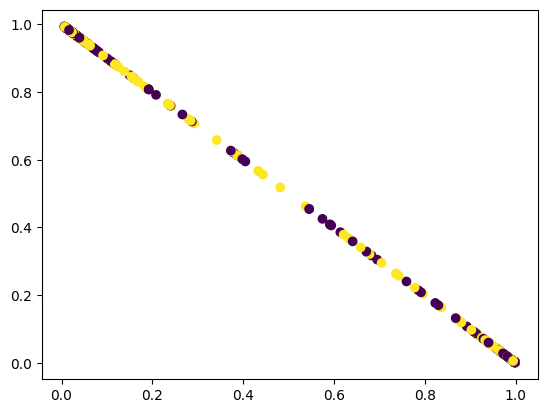

In [28]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X, y = make_moons(n_samples=1000, noise=0.25, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

clf = SVC(kernel='rbf', gamma='scale', probability=True).fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['0', '1']))

Q = clf.predict_proba(X_test)

Q0, Q1 = Q[:, 0], Q[:, 1]

plt.scatter(Q0, Q1, c=y_train)
plt.show()

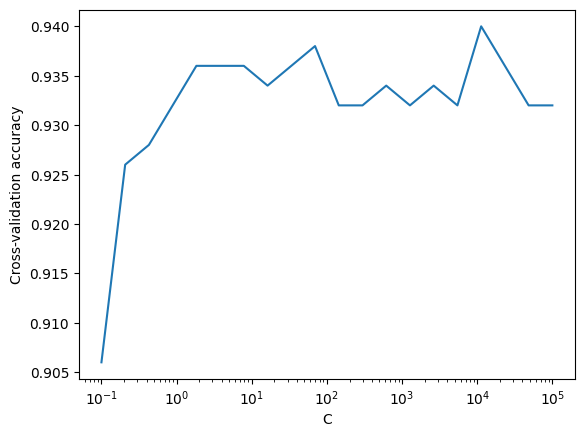

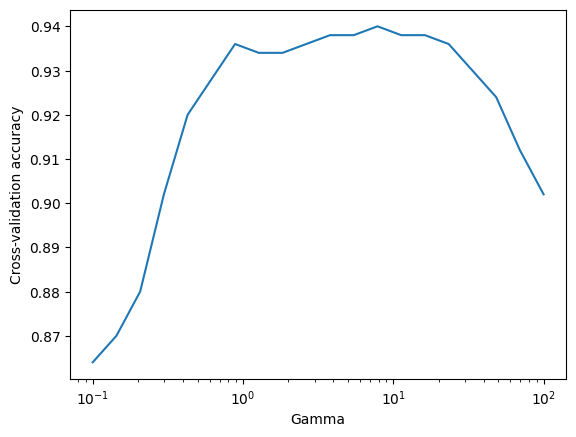

In [ ]:
from sklearn.model_selection import cross_val_score

Cs = np.logspace(-1, 5, 20)
scores = []
for C in Cs:
    clf = SVC(kernel='rbf', C=C, gamma='scale')
    score = cross_val_score(clf, X_train, y_train, cv=5)
    scores.append(score.mean())

plt.semilogx(Cs, scores)
plt.xlabel('C')
plt.ylabel('Cross-validation accuracy')
plt.show()

gammas = np.logspace(-1, 2, 20)
scores = []
for gamma in gammas:
    clf = SVC(kernel='rbf', gamma=gamma)
    score = cross_val_score(clf, X_train, y_train, cv=5)
    scores.append(score.mean())

plt.semilogx(gammas, scores)
plt.xlabel('Gamma')
plt.ylabel('Cross-validation accuracy')
plt.show()

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': np.logspace(-1, 5, 10),
    'gamma': np.logspace(-1, 2, 10)
}

grid = GridSearchCV(SVC(kernel='rbf', probability=True), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best parameters found: ", grid.best_params_)
print("Best cross-validation score: ", grid.best_score_)

# Plotting the decision boundary of the best model
best_clf = grid.best_estimator_
disp = DecisionBoundaryDisplay.from_estimator(best_clf, X_train)
disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k')
plt.title(f"Best model with C={grid.best_params_['C']}, gamma={grid.best_params_['gamma']}")
plt.show()

# Plotting the likelihood space of the best model
Q = best_clf.predict_proba(X_train)
Q0, Q1 = Q[:, 0], Q[:, 1]
plt.scatter(Q0, Q1, c=y_train)
plt.xlabel('P(y=0|x)')
plt.ylabel('P(y=1|x)')
plt.title(f"Likelihood space of the best model with C={grid.best_params_['C']}, gamma={grid.best_params_['gamma']}")
plt.show()